In [1]:
import tensorflow as tf
import numpy as np
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
DATA_DIR = "gimages_ds"
BATCH_SIZE = 16      # Small batch size since we have a small dataset
IMG_SIZE = (224, 224) # Standard input size for MobileNetV2
EPOCHS = 50

In [3]:
print("Loading data...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% of data for validation
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Classes found: {class_names}")

# Optimize dataset performance for training
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Loading data...
Found 1123 files belonging to 8 classes.
Using 899 files for training.
Found 1123 files belonging to 8 classes.
Using 224 files for validation.
Classes found: ['bhature', 'chapati', 'daal_baati_churma', 'lachha_paratha', 'naan', 'palak_roti', 'ragi_roti', 'rumali_rotti']


In [4]:
data_augmentation = Sequential([
  RandomFlip('horizontal'),
  RandomRotation(0.2),
  RandomZoom(0.2),
])

In [5]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model so we don't destroy the pre-trained weights
base_model.trainable = False

# Construct the final model
model = Sequential([
    # Input layer to standardize pixel values between -1 and 1
    tf.keras.layers.Rescaling(1./127.5, offset=-1, input_shape=IMG_SIZE + (3,)),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2), # Drops 20% of neurons randomly to prevent overfitting
    Dense(len(class_names), activation='softmax') # Output layer for 8 classes
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

early_stopper = EarlyStopping(
    monitor='val_loss',          # Monitor the validation loss
    patience=3,                  # Wait for 3 epochs without improvement before stopping
    restore_best_weights=True,   # CRITICAL: Reverts to the best model weights, not the last epoch's weights
    verbose=1                    # Prints a message when early stopping is triggered
)

# ==========================================
# 5. Training the Model
# ==========================================
print("\nStarting Training...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopper]
)

C:\Users\pgiri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting Training...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step - accuracy: 0.4238 - loss: 1.6402 - val_accuracy: 0.7277 - val_loss: 0.9877
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7052 - loss: 0.9027 - val_accuracy: 0.8259 - val_loss: 0.6729
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.7742 - loss: 0.6547 - val_accuracy: 0.8259 - val_loss: 0.5838
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.8443 - loss: 0.5226 - val_accuracy: 0.8616 - val_loss: 0.4997
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.8454 - loss: 0.4960 - val_accuracy: 0.8661 - val_loss: 0.4771
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.8765 - loss: 0.4207 - val_accuracy: 0.8839 - val_loss: 0.4342
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.8799 - loss: 0.3825 - val_accuracy: 0.8839 - val_loss: 0.4030
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8966 - los


Model saved as 'indian_food_classifier.h5'


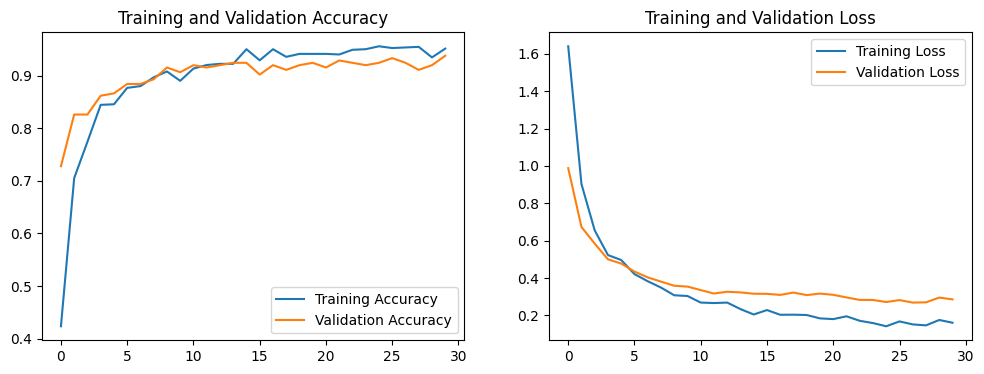

In [6]:
model.save('indian_food_classifier.h5')
print("\nModel saved as 'indian_food_classifier.h5'")

# Plotting Training vs Validation Accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


Generating predictions for the validation dataset...

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

          bhature       1.00      0.94      0.97        34
          chapati       0.87      0.84      0.86        32
daal_baati_churma       0.95      1.00      0.97        39
   lachha_paratha       0.85      0.88      0.86        25
             naan       0.88      0.90      0.89        31
       palak_roti       1.00      1.00      1.00        18
        ragi_roti       1.00      0.96      0.98        25
     rumali_rotti       0.85      0.85      0.85        20

         accuracy                           0.92       224
        macro avg       0.92      0.92      0.92       224
     weighted avg       0.93      0.92      0.92       224




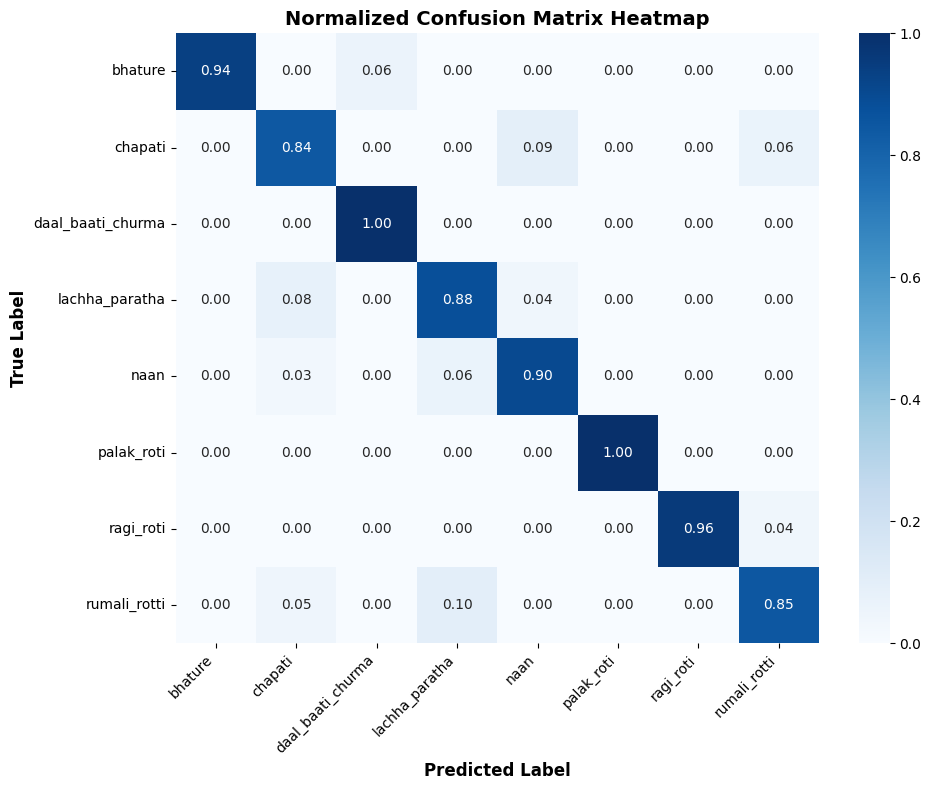

In [7]:
print("\nGenerating predictions for the validation dataset...")

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

# NEW: Print Precision, Recall, and F1-Score
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*50 + "\n")

# Calculate and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            vmin=0.0, vmax=1.0) 

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()